In [1]:
import numpy as np
import pandas as pd
import pickle
import celer
from datetime import datetime, timedelta
from typing import List, Dict, Tuple
from knockpy import KnockoffFilter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def moving_average_smoother(signal, window_length = 7):
    signal_padded = np.append(np.nan * np.ones(window_length - 1), signal)
    signal_smoothed = (np.convolve(signal_padded, np.ones(window_length, dtype=int), mode="valid")/ window_length)
    return signal_smoothed

def standardize_X(X):
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_std[X_std == 0] = 1
    standardized_X = (X - X_mean) / X_std
    standardized_X[np.isnan(standardized_X)] = 0
    return standardized_X, X_mean, X_std

def standardize_y(y):
    y_mean, y_std = y.mean(), y.std()
    standardized_y = (y - y_mean) / y_std
    standardized_y[np.isnan(standardized_y)] = 0
    return standardized_y, y_mean, y_std

def recover_coefficients(coef, X_std, y_std):
    return (coef / X_std) * y_std

def recover_intercept(X, y, coef, intercept_length):
    intercept = y - np.dot(X, coef)
    return np.mean(intercept[-intercept_length:])

def group_X(X, lag_set):
    grouped_X = np.array([X[r_idx - lag_set, :].T.flatten() for r_idx in range(max(lag_set), X.shape[0])])
    return grouped_X

def extend_indices(indices, group_size):
    extended_indices = []
    for idx in indices:
        extended_indices.extend(list(range(idx * group_size, idx * group_size + group_size)))
    return extended_indices

def shrink_indices(extended_indices, group_size):
    indices = [extended_indices[i] // group_size for i in range(0, len(extended_indices), group_size)]
    return indices

def date_before(date_int, diff_days):
    date_obj = datetime.strptime(str(date_int), '%Y%m%d')
    new_date_obj = date_obj - timedelta(days=int(diff_days))
    new_date_int = int(new_date_obj.strftime('%Y%m%d'))
    return new_date_int

def date_after(date_int, diff_days):
    date_obj = datetime.strptime(str(date_int), '%Y%m%d')
    new_date_obj = date_obj + timedelta(days=int(diff_days))
    new_date_int = int(new_date_obj.strftime('%Y%m%d'))
    return new_date_int

# HealthDataHandler(region_list, target_data, region_data_dict)
# both target_data and region_data_dict should be smoothed
class HealthDataHandler:
    def __init__(self, region_list: List[str], lag_set: np.ndarray, report_freq_days: int, target_data: pd.DataFrame, region_data: Dict[str, pd.DataFrame]):
        self.region_list = region_list
        self.lag_set = lag_set
        self.report_freq_days = report_freq_days
        self.target_data = target_data
        self.region_data = region_data

    def get_X_y(self, start_date: int, end_date: int, codes: List[str]):
        self.X = {}
        self.standardized_X = {}
        self.X_mean = {}
        self.X_std = {}
        self.y = {}
        self.standardized_y = {}
        self.y_mean = {}
        self.y_std = {}
        self.standardized_grouped_X = {}
        self.grouped_X = {}
        for region in self.region_list:
            X = self.region_data[region].loc[date_before(start_date, max(self.lag_set) * self.report_freq_days):end_date - self.report_freq_days][codes].to_numpy()
            y = self.target_data.loc[start_date:end_date - self.report_freq_days, region].to_numpy()
            standardized_X, X_mean, X_std = standardize_X(X)
            standardized_y, y_mean, y_std = standardize_y(y)
            standardized_grouped_X = group_X(standardized_X, lag_set = self.lag_set)
            grouped_X = group_X(X, lag_set = self.lag_set)
            X = X[-(len(y)):]
            standardized_X = standardized_X[-(len(y)):]
            self.X[region] = X
            self.standardized_X[region] = standardized_X
            self.X_mean[region] = X_mean
            self.X_std[region] = X_std
            self.y[region] = y
            self.standardized_y[region] = standardized_y
            self.y_mean[region] = y_mean
            self.y_std[region] = y_std
            self.standardized_grouped_X[region] = standardized_grouped_X
            self.grouped_X[region] = grouped_X
        self.nS = len(y)
        self.nG = X.shape[1]
        self.nV = grouped_X.shape[1]

    def run_all_single(self, intercept_length, model, alpha = 0.3, states_prev_g = None, maxsteps = 5, states_prev_W = None, tau = 0.5, M = 10, M_max = 30, fdr = 0.1):
        # grpLasso derandomKnock forward
        group_size = len(self.lag_set)
        self.active_g_indices = {}
        self.recovered_coef = {}
        self.recovered_intercept = {}
        if model == 'grpLasso':
            self.unit_coef = {}
            for region in self.region_list:
                if states_prev_g is None:
                    prev_g_indices = None
                else:
                    prev_g_indices = states_prev_g[region]
                active_g_indices, unit_coef, recovered_coef, recovered_intercept = SIS_grpLasso_KKT(self.X[region], self.y[region], self.standardized_grouped_X[region], self.standardized_y[region], self.grouped_X[region], self.X_std[region], self.y_std[region], group_size, intercept_length, alpha = alpha, prev_g_indices = prev_g_indices)
                # model_coef = unit_coef if coef_method == 'standardized' else recovered_coef
                self.active_g_indices[region] = active_g_indices
                self.recovered_coef[region] = recovered_coef
                self.recovered_intercept[region] = recovered_intercept
                self.unit_coef[region] = unit_coef
        elif model == 'forward':
            for region in self.region_list:
                active_g_indices, recovered_coef, recovered_intercept = forward_stepwise_regression(self.grouped_X[region], self.y[region], group_size, intercept_length, maxsteps = maxsteps)
                self.active_g_indices[region] = active_g_indices
                self.recovered_coef[region] = recovered_coef
                self.recovered_intercept[region] = recovered_intercept
        elif model == 'forward_backward':
            for region in self.region_list:
                if states_prev_g is None:
                    prev_g_indices = None
                else:
                    prev_g_indices = states_prev_g[region]
                active_g_indices, recovered_coef, recovered_intercept = forward_backward_stepwise_regression(self.grouped_X[region], self.y[region], group_size, intercept_length, maxsteps = maxsteps, prev_g_indices = prev_g_indices)
                self.active_g_indices[region] = active_g_indices
                self.recovered_coef[region] = recovered_coef
                self.recovered_intercept[region] = recovered_intercept
        elif model == 'derandomKnock':
            self.states_curr_W = {}
            for region in self.region_list:
                if states_prev_W is None:
                    full_prev_W = None
                else:
                    full_prev_W = states_prev_W[region]
                active_g_indices, recovered_coef, recovered_intercept, full_curr_W = derandomKnock(self.X[region], self.y[region], self.standardized_grouped_X[region], self.standardized_y[region], self.grouped_X[region], group_size, intercept_length, full_prev_W = full_prev_W, tau = tau, M = M, M_max = M_max, fdr = fdr, v = 1)
                self.active_g_indices[region] = active_g_indices
                self.recovered_coef[region] = recovered_coef
                self.recovered_intercept[region] = recovered_intercept
                self.states_curr_W[region] = full_curr_W
        else:
            raise ValueError("Invalid model provided. Use 'grpLasso', 'forward' or 'derandomKnock'.")

    def get_test(self, start_test: int, codes: List[str], period_length: int):
        self.y_test = {}
        self.grouped_X_test = {}
        end_test = date_after(start_test, period_length)
        for region in self.region_list:
            X = self.region_data[region].loc[date_before(start_test, max(self.lag_set) * self.report_freq_days):end_test - self.report_freq_days][codes].to_numpy()
            y = self.target_data.loc[start_test:end_test - self.report_freq_days, region].to_numpy()
            grouped_X = group_X(X, lag_set = self.lag_set)
            self.y_test[region] = y
            self.grouped_X_test[region] = grouped_X
        self.test_dates = self.target_data.loc[start_test:end_test - self.report_freq_days, region].index.to_numpy()

    def get_informative_states(self, primary_state, region_method, auxiliary_region_list = None, nStates = 5):
        # marginal_diff
        if region_method == 'marginal_diff':
            if auxiliary_region_list is None:
                auxiliary_region_list = [s for s in self.region_list if s != primary_state]
            if nStates is not None:
                self.informative_region_list = np.array(auxiliary_region_list)[self.sort_marginal_diff(primary_state, auxiliary_region_list)[:nStates]]
                return self.informative_region_list
            else:
                raise ValueError("nStates must not be None for 'marginal_diff' method.")
        # sibling
        elif region_method == 'sibling':
            for sublist in mega_list:
                if primary_state in sublist:
                    self.informative_region_list = [s for s in sublist if s != primary_state]
                    return self.informative_region_list
            raise ValueError(f"{primary_state} not found in any sibling groups.")
        else:
            raise ValueError("Invalid region_method provided. Use 'marginal_diff' or 'sibling'.")
    
    def sort_marginal_diff(self, primary_state, auxiliary_region_list):
        primary_Xty = np.dot(self.standardized_X[primary_state].T, self.standardized_y[primary_state]) / self.nS
        auxiliary_region_Xty = np.array([np.dot(self.standardized_X[auxiliary_state].T, self.standardized_y[auxiliary_state]) / self.nS for auxiliary_state in auxiliary_region_list])
        abs_diff = np.abs(auxiliary_region_Xty - primary_Xty)
        Rhat = []
        for s_idx, auxiliary_state in enumerate(auxiliary_region_list):
            abs_diff_s = abs_diff[s_idx]
            screened_largest_diff = abs_diff_s[np.argsort(abs_diff_s)[-int(self.nS/3):]]
            Rhat.append(np.sum(screened_largest_diff ** 2))
        return np.argsort(Rhat)
    
    def Q_aggregation(self, B, X_test, y_test, total_step = 10, selection = False):
        # y_test -= y_test.mean()
        y_test = y_test.reshape(-1, 1)
        XB = np.dot(X_test, B)
        # XB -= XB.mean(axis = 0)
        # if(selection){#select beta.hat with smallest prediction error
        if not selection: 
            # }else{#Q-aggregation
            # theta.hat<- exp(-colSums((y.test-X.test%*%B)^2)/2)
            # theta_hat = np.exp(-np.sum((y_test - np.dot(X_test, B)) ** 2, axis = 0) / 2)
            theta_hat = np.exp(-np.mean((y_test - XB) ** 2, axis = 0) / 2)
            # theta.hat=theta.hat/sum(theta.hat)
            theta_hat /= np.sum(theta_hat)
            # theta.old=theta.hat
            theta_old = theta_hat.copy()
            # beta<-as.numeric(B%*%theta.hat)
            beta = np.dot(B, theta_hat)
            # beta.ew<-beta
            beta_ew = beta.copy()
            # for(ss in 1:total.step){
            for ss in range(total_step):
                Xbeta = np.dot(X_test, beta)
                # Xbeta -= Xbeta.mean()
                # theta.hat<- exp(-colSums((y.test-X.test%*%B)^2)/2+colSums((as.vector(X.test%*%beta)-X.test%*%B)^2)/8)
                theta_hat = np.exp(-np.mean((y_test - XB) ** 2, axis = 0) / 2 + 
                                np.mean((Xbeta.reshape(-1, 1) - XB) ** 2, axis = 0) / 8)
                # theta.hat<-theta.hat/sum(theta.hat)
                theta_hat /= np.sum(theta_hat)
                # beta<- as.numeric(B%*%theta.hat*1/4+3/4*beta)
                beta = np.dot(B, theta_hat) * 1/4 + 3/4 * beta
                # if(sum(abs(theta.hat-theta.old))<10^(-3)){break}
                if np.sum(np.abs(theta_hat - theta_old)) < 1e-3:
                    break
                # theta.old=theta.hat
                theta_old = theta_hat.copy()
            # }
        if selection or np.isnan(theta_hat).any():
            # khat<-which.min(colSums((y.test-X.test%*%B)^2))
            # theta.hat<-rep(0, ncol(B))
            # theta.hat[khat] <- 1
            # beta=B[,khat]
            khat = np.argmin(np.mean((y_test - XB) ** 2, axis = 0))
            theta_hat = np.zeros(B.shape[1])
            theta_hat[khat] = 1
            beta = B[:, khat]
        return theta_hat, beta
    
    def run_all_agg(self, intercept_length, region_method, auxiliary_region_list = None, nStates = 5, total_step = 10, selection = False):
        group_size = len(self.lag_set)
        self.recovered_coef_agg = {}
        self.recovered_intercept_agg = {}
        for primary_state in self.region_list:
            self.get_informative_states(primary_state, region_method, auxiliary_region_list, nStates)
            B = np.zeros((len(self.informative_region_list) + 1, self.nV))
            B[0] = self.recovered_coef[primary_state] / self.y_std[primary_state] * np.repeat(self.X_std[primary_state], group_size)
            for s_idx, informative_state in enumerate(self.informative_region_list):
                B[s_idx + 1] = self.recovered_coef[informative_state] / self.y_std[primary_state] * np.repeat(self.X_std[primary_state], group_size)
            B = B.T
            X_test = (self.grouped_X_test[primary_state] - np.repeat(self.X_mean[primary_state], group_size)) / np.repeat(self.X_std[primary_state], group_size)
            y_test = (self.y_test[primary_state] - self.y_mean[primary_state]) / self.y_std[primary_state]
            theta_hat, beta = self.Q_aggregation(B, X_test, y_test, total_step, selection)
            self.recovered_coef_agg[primary_state] = recover_coefficients(beta, np.repeat(self.X_std[primary_state], group_size), self.y_std[primary_state])
            self.recovered_intercept[primary_state] = recover_intercept(self.grouped_X_test[primary_state], self.y_test[primary_state], self.recovered_coef[primary_state], intercept_length)
            self.recovered_intercept_agg[primary_state] = recover_intercept(self.grouped_X_test[primary_state], self.y_test[primary_state], self.recovered_coef_agg[primary_state], intercept_length)
### grpLasso
# SIS - grpLasso - KKT
# class celer.GroupLasso(groups=1, alpha=1.0, max_iter=100, max_epochs=50000, p0=10, verbose=0, tol=0.0001, prune=True, fit_intercept=True, weights=None, warm_start=False)
# (1 / (2 * n_samples)) * ||y - X w||^2_2 + alpha * \sum_g weights_g ||w_g||_2
def fit_grpLasso(standardized_grouped_X, standardized_y, grouped_X, y, X_std, y_std, group_size, intercept_length, alpha, weights = None):
    grpLasso_model = celer.GroupLasso(groups = group_size, alpha = alpha, tol = 1e-4, fit_intercept = False, weights = weights)
    grpLasso_model.fit(standardized_grouped_X, standardized_y)
    recovered_coef = recover_coefficients(grpLasso_model.coef_, np.repeat(X_std, group_size), y_std)
    recovered_intercept = recover_intercept(grouped_X, y, recovered_coef, intercept_length)
    return grpLasso_model, recovered_coef, recovered_intercept

def check_KKT(standardized_grouped_X, standardized_y, coef, g_indices, group_size, alpha, weights = None, tol = 1e-4):
    residual = standardized_y - np.dot(standardized_grouped_X, coef)
    check_stats = []
    for g_idx in range(0, standardized_grouped_X.shape[1], group_size):
        standardized_grouped_X_g = standardized_grouped_X[:, g_idx * group_size : g_idx * group_size + group_size]
        check_stat = np.linalg.norm(standardized_grouped_X_g.T.dot(residual), 2) / standardized_grouped_X_g.shape[0]
        check_stats.append(check_stat)
    check_stats = np.array(check_stats)
    if weights is None:
        weights = 1
    check_threshs = alpha * weights
    violated_g_indices = np.where(check_stats > check_threshs + tol)[0]
    violated_g_indices = list(set(violated_g_indices) - set(g_indices))
    return violated_g_indices

def SIS(X, y, nSel):
    correlations = np.abs(np.corrcoef(X.T, y)[:-1, -1])
    np.nan_to_num(correlations, copy=False)
    sorted_indices = np.argsort(correlations)[::-1]
    SIS_g_indices = sorted_indices[:nSel]
    return SIS_g_indices

def SIS_grpLasso_KKT(X, y, standardized_grouped_X, standardized_y, grouped_X, X_std, y_std, group_size, intercept_length, alpha, prev_g_indices = None, weights = None):
    if prev_g_indices is None or len(prev_g_indices) == 0:
        violated_g_indices = SIS(X, y, nSel = int(len(y) / group_size) - 1)
    else:
        violated_g_indices = prev_g_indices
    SIS_g_indices = np.array([], dtype = int)
    while len(violated_g_indices) > 0:
        SIS_g_indices = list(set(SIS_g_indices) | set(violated_g_indices))
        SIS_v_indices = extend_indices(SIS_g_indices, group_size)
        grpLasso_model, recovered_coef, recovered_intercept = fit_grpLasso(standardized_grouped_X[:, SIS_v_indices], standardized_y, grouped_X[:, SIS_v_indices], y, X_std[SIS_g_indices], y_std, group_size, intercept_length, alpha, weights)
        full_unit_coef = np.zeros(standardized_grouped_X.shape[1])
        full_unit_coef[SIS_v_indices] = grpLasso_model.coef_
        violated_g_indices = check_KKT(standardized_grouped_X, standardized_y, full_unit_coef, SIS_g_indices, group_size, alpha, weights)
    full_recovered_coef = np.zeros(standardized_grouped_X.shape[1])
    full_recovered_coef[SIS_v_indices] = recovered_coef
    active_v_indices = np.where(full_recovered_coef != 0)[0]
    active_g_indices = shrink_indices(active_v_indices, group_size)
    return active_g_indices, full_unit_coef, full_recovered_coef, recovered_intercept


### forward
def forward_stepwise_regression(grouped_X, y, group_size, intercept_length, maxsteps = 5):
    active_g_indices = []
    inactive_g_indices = list(range(int(grouped_X.shape[1] / group_size)))
    residual = y
    beta = None
    for step in range(maxsteps):
        best_g_idx = None
        best_corr = 0
        for g_idx in inactive_g_indices:
            corr = np.linalg.norm(np.corrcoef(grouped_X[:, g_idx * group_size : g_idx * group_size + group_size].T, residual)[:-1, -1], 2)
            if corr > best_corr:
                best_g_idx = g_idx
                best_corr = corr
        if best_g_idx is not None:
            active_g_indices.append(best_g_idx)
            inactive_g_indices.remove(best_g_idx)
            active_v_indices = extend_indices(active_g_indices, group_size)
            X_active = grouped_X[:, active_v_indices]
            # beta, _, _, _ = np.linalg.lstsq(X_active, y, rcond=None)
            extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
            beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
            residual = y - extended_X_active @ beta
        else:
            break
    forward_coef = np.zeros(grouped_X.shape[1])
    if beta is not None:
        forward_coef[active_v_indices] = beta[1:]
    recovered_intercept = recover_intercept(grouped_X, y, forward_coef, intercept_length)
    return active_g_indices, forward_coef, recovered_intercept

### forward_backward
def forward_backward_stepwise_regression(grouped_X, y, group_size, intercept_length, maxsteps = 5, prev_g_indices = None):
    active_g_indices = []
    inactive_g_indices = list(range(int(grouped_X.shape[1] / group_size)))
    if prev_g_indices is None or len(prev_g_indices) == 0:
        residual = y
        beta = None
    else:
        for g_idx in prev_g_indices:
            active_g_indices.append(g_idx)
            inactive_g_indices.remove(g_idx)
        active_v_indices = extend_indices(active_g_indices, group_size)
        X_active = grouped_X[:, active_v_indices]
        extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
        beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
        residual = y - extended_X_active @ beta

    # for step in range(maxsteps):
    while len(active_g_indices) < 2 * maxsteps:
        best_g_idx = None
        best_corr = 0
        for g_idx in inactive_g_indices:
            corr = np.linalg.norm(np.corrcoef(grouped_X[:, g_idx * group_size : g_idx * group_size + group_size].T, residual)[:-1, -1], 2)
            if corr > best_corr:
                best_g_idx = g_idx
                best_corr = corr
        if best_g_idx is not None:
            active_g_indices.append(best_g_idx)
            inactive_g_indices.remove(best_g_idx)
            active_v_indices = extend_indices(active_g_indices, group_size)
            X_active = grouped_X[:, active_v_indices]
            # beta, _, _, _ = np.linalg.lstsq(X_active, y, rcond=None)
            extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
            beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
            residual = y - extended_X_active @ beta
        else:
            break

    while len(active_g_indices) > maxsteps:
        worst_g_idx = None
        smallest_improvement = np.inf
        for g_idx in active_g_indices:
            temp_active_g_indices = active_g_indices.copy()
            temp_active_g_indices.remove(g_idx)
            temp_active_v_indices = extend_indices(temp_active_g_indices, group_size)
            X_active_temp = grouped_X[:, temp_active_v_indices]
            extended_X_active_temp = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active_temp])
            beta_temp, _, _, _ = np.linalg.lstsq(extended_X_active_temp, y, rcond=None)
            residual_temp = y - extended_X_active_temp @ beta_temp
            improvement = np.sum(residual_temp**2) - np.sum(residual**2)
            if improvement < smallest_improvement:
                smallest_improvement = improvement
                worst_g_idx = g_idx
        active_g_indices.remove(worst_g_idx)
        active_v_indices = extend_indices(active_g_indices, group_size)
        X_active = grouped_X[:, active_v_indices]
        extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
        beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
        residual = y - extended_X_active @ beta
    
    stepwise_coef = np.zeros(grouped_X.shape[1])
    if beta is not None:
        stepwise_coef[active_v_indices] = beta[1:]
    recovered_intercept = recover_intercept(grouped_X, y, stepwise_coef, intercept_length)
    return active_g_indices, stepwise_coef, recovered_intercept

### derandomKnock
def derandomKnock_filter(standardized_grouped_X, standardized_y, group_size, prev_W = None, tau = 0.5, M = 10, M_max = 30, fdr = 0.1, v = 1):
    p = int(standardized_grouped_X.shape[1] / group_size)
    groups = np.repeat(np.arange(1, p + 1, 1), group_size)
    pi = np.zeros(p)
    curr_W = [] if prev_W is None else prev_W
    if len(curr_W) > M_max - M:
        curr_W = curr_W[-(M_max - M):]
    for m in range(M):
        kfilter = KnockoffFilter(ksampler = 'gaussian', fstat = 'lasso')
        kfilter.forward(standardized_grouped_X, standardized_y, groups = groups, fdr = fdr)
        W = kfilter.W
        curr_W.append(W)
    for W in curr_W:
        if np.sum(W < 0) < v:
            S = np.where(W > 0)[0] 
            pi[S] += 1
        else:
            order_w = np.argsort(np.abs(W))[::-1]
            sorted_w = W[order_w]
            negid = np.where(sorted_w < 0)[0]
            TT = negid[v - 1]
            S = np.where(sorted_w[:TT] > 0)[0]
            S = order_w[S]
            pi[S] += 1
    pi /= len(curr_W)
    S = np.where(pi >= min(tau, max(pi)))[0]
    return S, pi, curr_W

def derandomKnock_regression(grouped_X, y, S_g_indices, group_size):
    derandomKnock_model = LinearRegression()
    S_v_indices = extend_indices(S_g_indices, group_size)
    derandomKnock_model.fit(grouped_X[:, S_v_indices], y)
    derandomKnock_model_coef = np.zeros(grouped_X.shape[1])
    derandomKnock_model_coef[S_v_indices] = derandomKnock_model.coef_
    return derandomKnock_model_coef, derandomKnock_model.intercept_

def derandomKnock(X, y, standardized_grouped_X, standardized_y, grouped_X, group_size, intercept_length, full_prev_W = None, tau = 0.5, M = 10, M_max = 30, fdr = 0.1, v = 1):
    SIS_g_indices = SIS(X, y, nSel = int(len(y) / group_size) - 1)
    if np.unique(standardized_y).shape[0] > 2:
        SIS_v_indices = extend_indices(SIS_g_indices, group_size)
        if full_prev_W is None:
            prev_W = None
        else:
            prev_W = [W[SIS_g_indices] for W in full_prev_W]
        S, pi, curr_W = derandomKnock_filter(standardized_grouped_X[:, SIS_v_indices], standardized_y, group_size, prev_W, tau, M, M_max, fdr, v)
        S_g_indices = SIS_g_indices[S]
        full_curr_W = [np.zeros(X.shape[1]) for w_idx in range(len(curr_W))]
        for w_idx, W in enumerate(curr_W):
            full_curr_W[w_idx][SIS_g_indices] = W
    else:
        S_g_indices = SIS_g_indices
        full_curr_W = full_prev_W
    recovered_coef, _ = derandomKnock_regression(grouped_X, y, S_g_indices, group_size)
    recovered_intercept = recover_intercept(grouped_X, y, recovered_coef, intercept_length)
    return S_g_indices, recovered_coef, recovered_intercept, full_curr_W

/net/dali/home/mscbio/rul98/miniconda3/envs/struct/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
state_abbreviations = {
    'Alabama': 'AL',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Total Us Mulo': 'US',
    'Total Us': 'US',
    'Total US': 'US'
}

In [27]:
# ASSIGN MyEpiWeek = EPIWEEK( <start_date>, {<first_day_of_week>} )
flu_df = pd.read_csv('/net/dali/home/mscbio/rul98/PheOpt/iRi/flu_data_all.csv')[['region', 'epiweek', 'num_ili', 'num_patients', 'wili', 'ili', 'WEEK', 'YEAR', 'State']].drop_duplicates()
flu_df = flu_df.loc[flu_df.YEAR < 2018]
flu_df = flu_df.loc[flu_df.YEAR > 2011]
flu_df = flu_df.groupby(['region', 'epiweek'], as_index=False).last()
flu_df = flu_df.sort_values(by=['region', 'YEAR', 'WEEK'])
flu_df = flu_df.dropna(subset=['State'])

flu_df['Week_Start_Date'] = pd.to_datetime(flu_df['epiweek'], format='%m/%d/%y')
flu_df['Week_Start_Date'] = flu_df['Week_Start_Date'].dt.strftime('%Y%m%d').astype(int)
flu_df = flu_df.set_index('Week_Start_Date')

flu_pivot = flu_df.pivot_table(values='ili', index=flu_df.index, columns='region')
flu_pivot = flu_pivot[(flu_pivot.index >= 20120617) & (flu_pivot.index <= 20170312)]

print(flu_pivot)

region                 AK       AL        AR        AZ       CA        CO  \
Week_Start_Date                                                             
20120617         0.268097  1.05795  0.160686  0.697134  2.03814  0.395820   
20120624         0.428036  3.61162  0.199734  0.733859  1.87500  0.318319   
20120701         0.380435  3.61815  0.000000  0.545768  1.93357  0.329042   
20120708         0.326797  3.42731  0.000000  0.506594  1.82661  0.344321   
20120715         0.304260  3.02515  0.000000  0.507653  1.69307  0.342296   
...                   ...      ...       ...       ...      ...       ...   
20170212         4.287440  7.56183  9.196920  2.298420  2.52341  3.539820   
20170219         3.762760  7.42094  7.894740  2.532100  2.38854  1.315080   
20170226         3.524230  6.29416  4.478660  2.752030  2.14593  1.736610   
20170305         1.740700  6.59379  4.593870  2.491540  2.17089  1.579240   
20170312         2.359880  5.96548  3.554010  2.192470  2.33730  1.208700   

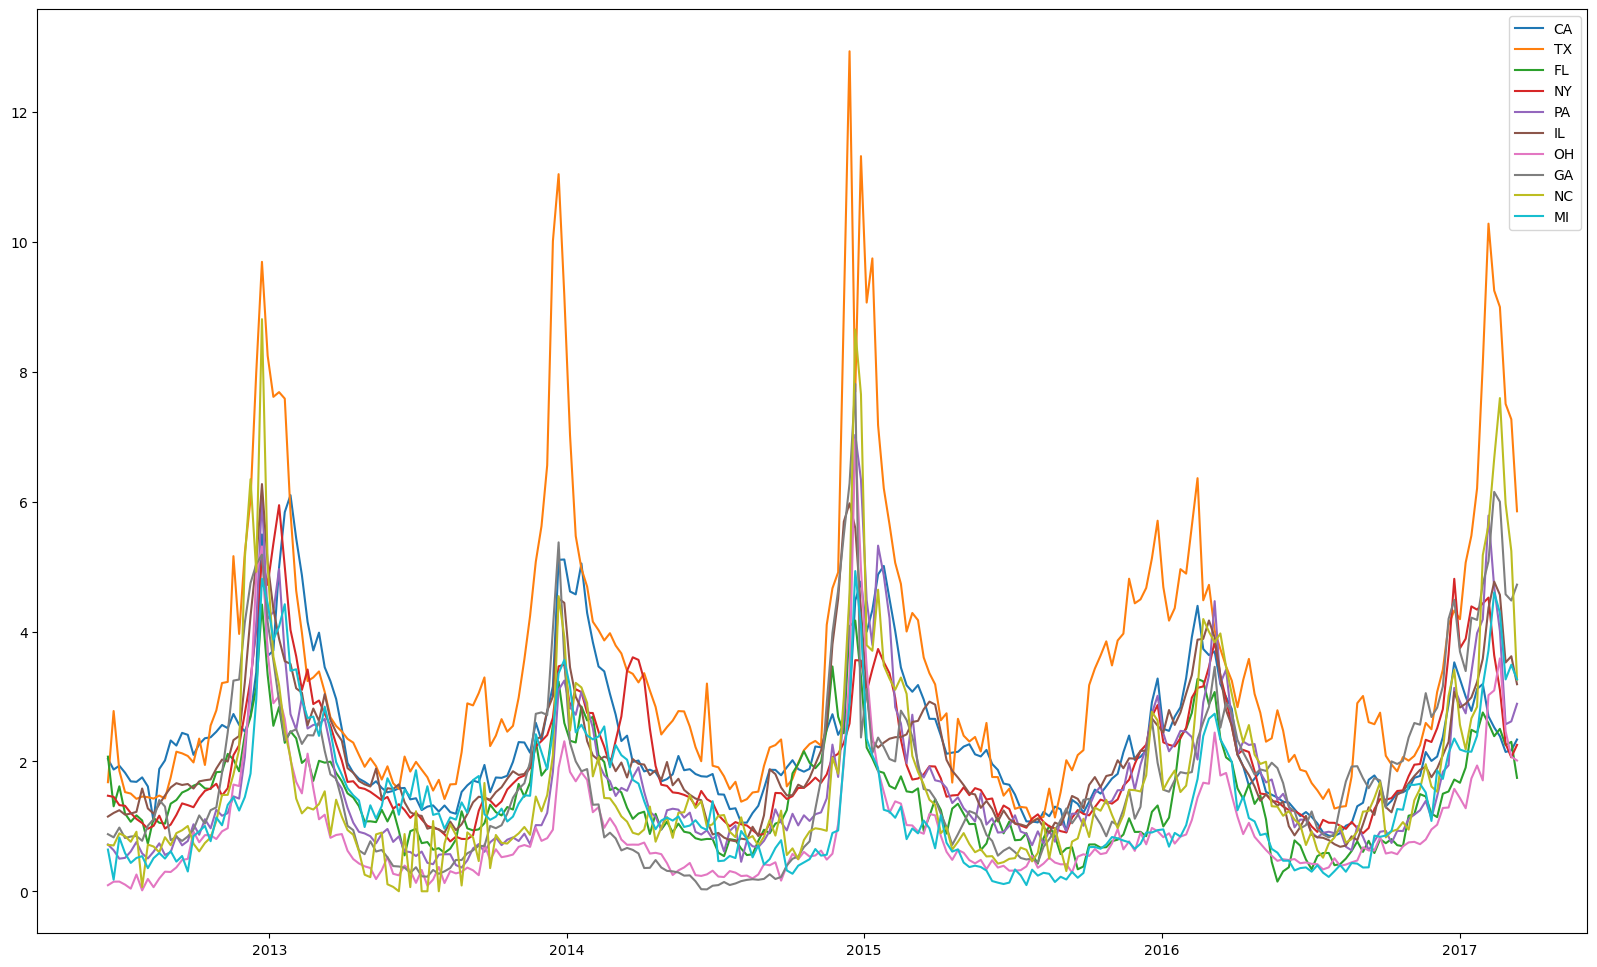

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 12))
for region in ['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']:
    plt.plot(pd.to_datetime(flu_pivot.index, format='%Y%m%d').tolist(), flu_pivot[region], label = region)
plt.legend()

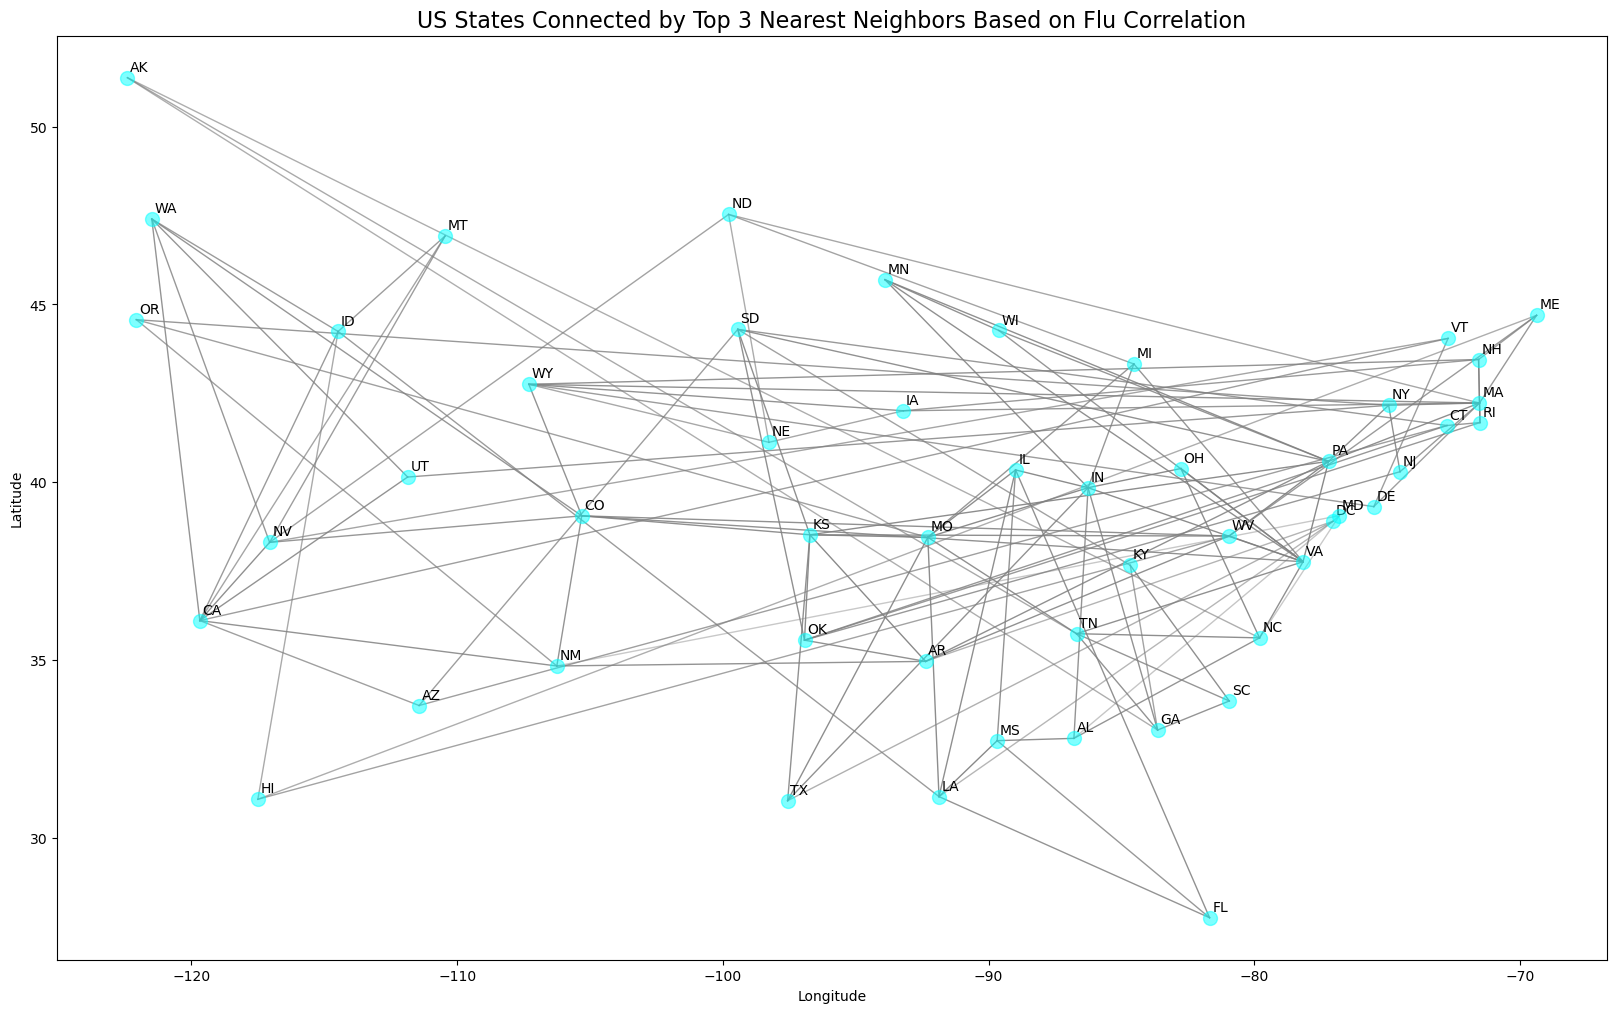

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Assuming flu_pivot is already available
# If not, include the data processing steps provided in your original code

# Step 3: Calculate the Correlation Matrix
corr_matrix = flu_pivot.corr()

# Step 4: Determine Nearest Neighbors
k = 3
nearest_neighbors = {}
for state in corr_matrix.columns:
    sorted_corr = corr_matrix[state].sort_values(ascending=False)
    top_neighbors = sorted_corr.drop(labels=[state]).head(k).index.tolist()
    nearest_neighbors[state] = top_neighbors

# Step 5: Obtain Geographical Coordinates
state_centroids = {
    'AL': (32.806671, -86.791130),
    'AK': (51.370716, -122.404419),
    'AZ': (33.729759, -111.431221),
    'AR': (34.969704, -92.373123),
    'CA': (36.116203, -119.681564),
    'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371),
    'DC': (38.9072, -77.0369),
    'DE': (39.318523, -75.507141),
    'FL': (27.766279, -81.686783),
    'GA': (33.040619, -83.643074),
    'HI': (31.094318, -117.498337),
    'ID': (44.240459, -114.478828),
    'IL': (40.349457, -88.986137),
    'IN': (39.849426, -86.258278),
    'IA': (42.011539, -93.210526),
    'KS': (38.526600, -96.726486),
    'KY': (37.668140, -84.670067),
    'LA': (31.169546, -91.867805),
    'ME': (44.693947, -69.381927),
    'MD': (39.063946, -76.802101),
    'MA': (42.230171, -71.530106),
    'MI': (43.326618, -84.536095),
    'MN': (45.694454, -93.900192),
    'MS': (32.741646, -89.678696),
    'MO': (38.456085, -92.288368),
    'MT': (46.921925, -110.454353),
    'NE': (41.125370, -98.268082),
    'NV': (38.313515, -117.055374),
    'NH': (43.452492, -71.563896),
    'NJ': (40.298904, -74.521011),
    'NM': (34.840515, -106.248482),
    'NY': (42.165726, -74.948051),
    'NC': (35.630066, -79.806419),
    'ND': (47.528912, -99.784012),
    'OH': (40.388783, -82.764915),
    'OK': (35.565342, -96.928917),
    'OR': (44.572021, -122.070938),
    'PA': (40.590752, -77.209755),
    'RI': (41.680893, -71.511780),
    'SC': (33.856892, -80.945007),
    'SD': (44.299782, -99.438828),
    'TN': (35.747845, -86.692345),
    'TX': (31.054487, -97.563461),
    'UT': (40.150032, -111.862434),
    'VT': (44.045876, -72.710686),
    'VA': (37.769337, -78.169968),
    'WA': (47.400902, -121.490494),
    'WV': (38.491226, -80.954453),
    'WI': (44.268543, -89.616508),
    'WY': (42.755966, -107.302490)
}

coordinates = pd.DataFrame({
    'State': list(state_centroids.keys()),
    'Latitude': [coord[0] for coord in state_centroids.values()],
    'Longitude': [coord[1] for coord in state_centroids.values()]
})

# Ensure only states present in flu_pivot are included
coordinates = coordinates[coordinates['State'].isin(flu_pivot.columns)].reset_index(drop=True)

# Step 6: Create a Graph
G = nx.Graph()
for _, row in coordinates.iterrows():
    G.add_node(row['State'], pos=(row['Longitude'], row['Latitude']))

for state, neighbors in nearest_neighbors.items():
    for neighbor in neighbors:
        weight = corr_matrix.loc[state, neighbor]
        G.add_edge(state, neighbor, weight=weight)

# Step 7: Plot the Graph
pos = {state: (data['pos'][0], data['pos'][1]) for state, data in G.nodes(data=True)}

plt.figure(figsize=(20, 12))

edges = G.edges(data=True)
weights = [data['weight'] for _, _, data in edges]
weights_normalized = [(w - corr_matrix.min().min()) / (corr_matrix.max().max() - corr_matrix.min().min()) for w in weights]

# Draw edges
for (u, v, data), alpha in zip(edges, weights_normalized):
    plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
             color='grey', alpha=alpha, linewidth=1)

# Draw nodes
plt.scatter(coordinates['Longitude'], coordinates['Latitude'],
            color='cyan', zorder=5, s=100, alpha = 0.5)

# Annotate states
for _, row in coordinates.iterrows():
    plt.text(row['Longitude'] + 0.1, row['Latitude'] + 0.1, row['State'],
             fontsize=10, ha='left', va='bottom')

plt.title('US States Connected by Top 3 Nearest Neighbors Based on Flu Correlation', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [22]:
for state, data in G.nodes(data=True):
    print(state, data)

AL {'pos': (-86.79113, 32.806671)}
AK {'pos': (-152.404419, 61.370716)}
AZ {'pos': (-111.431221, 33.729759)}
AR {'pos': (-92.373123, 34.969704)}
CA {'pos': (-119.681564, 36.116203)}
CO {'pos': (-105.311104, 39.059811)}
CT {'pos': (-72.755371, 41.597782)}
DE {'pos': (-75.507141, 39.318523)}
FL {'pos': (-81.686783, 27.766279)}
GA {'pos': (-83.643074, 33.040619)}
HI {'pos': (-157.498337, 21.094318)}
ID {'pos': (-114.478828, 44.240459)}
IL {'pos': (-88.986137, 40.349457)}
IN {'pos': (-86.258278, 39.849426)}
IA {'pos': (-93.210526, 42.011539)}
KS {'pos': (-96.726486, 38.5266)}
KY {'pos': (-84.670067, 37.66814)}
LA {'pos': (-91.867805, 31.169546)}
ME {'pos': (-69.381927, 44.693947)}
MD {'pos': (-76.802101, 39.063946)}
MA {'pos': (-71.530106, 42.230171)}
MI {'pos': (-84.536095, 43.326618)}
MN {'pos': (-93.900192, 45.694454)}
MS {'pos': (-89.678696, 32.741646)}
MO {'pos': (-92.288368, 38.456085)}
MT {'pos': (-110.454353, 46.921925)}
NE {'pos': (-98.268082, 41.12537)}
NV {'pos': (-117.055374, 3

In [5]:
# Read the Excel file with multiple sheets
# Replace 'your_file.xlsx' with the path to your actual file
file_path = '/net/dali/home/mscbio/rul98/PheOpt/iRi/FAN FLU states Units all cats.xlsx'
def get_week_start_date(time_str):
    # Extract the date part
    date_part = time_str.replace('1 week ending ', '').replace('Week Ending ', '')
    # Parse the date
    date = pd.to_datetime(date_part)
    # Subtract 6 days to get the week starting date
    week_start_date = date - pd.Timedelta(days=7)
    # Return date in '%Y%m%d' format
    return week_start_date.strftime('%Y%m%d')
# Read all sheets into a dictionary of DataFrames
xls = pd.ExcelFile(file_path)
FAN_sheets = xls.sheet_names  # List of all sheet names
skip = np.append(np.repeat(11, 8), np.repeat(3, 6))
# Loop through each sheet and read data, skipping the metadata rows
FAN_dfs = {}
for s_idx, sheet in enumerate(FAN_sheets):
    FAN_df = pd.read_excel(file_path, sheet_name=sheet, skiprows=skip[s_idx], index_col = None)
    FAN_df.columns = FAN_df.columns.str.replace(' - Multi Outlet', '', regex=False)
    FAN_df.columns = FAN_df.columns.str.replace('State - ', '', regex=False).str.replace(' - MULO', '', regex=False).str.title()
    FAN_df = FAN_df.dropna(axis=0, how = 'all')
    FAN_df['Time'] = FAN_df['Time'].apply(get_week_start_date).astype(int)
    FAN_df = FAN_df.set_index('Time')
    FAN_df.columns = [state_abbreviations[c] for c in FAN_df.columns]
    FAN_df = FAN_df[(FAN_df.index >= 20120617) & (FAN_df.index <= 20170312)]
    FAN_dfs[sheet] = FAN_df
    
print(FAN_dfs[FAN_sheets[0]].shape)
print(FAN_df.shape)

(248, 46)
(248, 46)


In [6]:
FAN_df

,US,AL,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
Time,,,,,,,,,,,,,,,,,,,,,
20120617,219369.188639,3982.834240,4016.219016,2154.361841,21766.929802,3329.510660,2505.042456,772.394625,18780.634626,7612.904028,...,450.561314,5081.476105,20521.117877,1855.905745,282.515721,6993.682939,4616.480514,1797.022280,3253.416247,342.205320
20120624,216962.450490,3864.241316,3739.301277,2523.153928,21504.897961,3075.955580,2704.764030,837.800538,18102.452497,7513.402520,...,418.163094,4987.852730,20208.536912,2005.761277,345.091084,7052.380382,4550.122601,1087.672817,3011.241180,387.365707
20120701,205698.997676,3604.371720,3615.384132,2275.606416,20180.912244,3312.489081,2606.224040,806.135538,17107.728830,6837.206228,...,610.603572,4905.140509,19315.334798,1738.279835,326.132446,6487.593323,3906.058784,1036.876078,3221.106869,350.982680
20120708,217531.353705,3982.661465,3640.790002,2483.260524,21564.962115,3405.763865,2780.734303,776.952085,17151.192896,7153.271984,...,521.182661,5183.521537,20045.700891,1850.786275,323.782403,7554.054484,3990.335949,1278.750611,3478.758898,376.004097
20120715,220638.931540,3872.895147,3634.666445,2325.313123,20771.037748,3513.422302,2595.850337,790.672868,17852.040578,7174.651032,...,452.788730,5125.978267,20138.427915,1752.000778,327.000311,7240.039745,4140.441886,1302.697027,3401.937236,425.023845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20170212,508664.003639,9933.318257,7639.952775,7511.221255,35078.132836,7755.673142,4839.343687,1611.402650,30381.971118,18461.010253,...,1861.592481,16436.801259,46689.540200,2955.635477,771.241861,17529.201874,7797.269460,3732.225856,8414.345740,823.303159
20170219,494922.706846,10409.184787,7245.711334,7525.073844,32851.495679,7113.347651,4528.089891,1687.415169,31430.934153,17536.639144,...,1549.813410,15114.166635,43860.371917,3097.127750,816.753046,18204.663688,7068.955385,4214.071704,8093.929260,780.199231
20170226,445858.762298,8673.266213,7525.321091,6235.289140,33417.266980,7028.375772,4108.199271,1436.484532,29517.894393,15079.011702,...,1655.488970,12650.078429,42698.380155,2897.259229,763.640174,15304.623481,7493.587784,3840.033315,7606.026376,746.791281


In [4]:
# Read the Excel file with multiple sheets
# Replace 'your_file.xlsx' with the path to your actual file
file_path = '/net/dali/home/mscbio/rul98/PheOpt/iRi/illness forecast.xlsx'
# Read all sheets into a dictionary of DataFrames
xls = pd.ExcelFile(file_path)
IF_sheets = xls.sheet_names  # List of all sheet names
skip = np.append(np.repeat(11, 8), np.repeat(3, 6))
# Loop through each sheet and read data, skipping the metadata rows
IF_dfs = {}
for s_idx, sheet in enumerate(IF_sheets):
    IF_df = pd.read_excel(file_path, sheet_name=sheet, skiprows=3, index_col = None)
    IF_df.columns = IF_df.columns.str.replace(' - Multi Outlet', '', regex=False)
    IF_df = IF_df.dropna(axis=0, how = 'all')
    IF_df['Time'] = IF_df['Time'].apply(get_week_start_date).astype(int)
    IF_df = IF_df.set_index('Time')
    IF_df.columns = [state_abbreviations[c] for c in IF_df.columns]
    IF_df = IF_df[(IF_df.index >= 20120617) & (IF_df.index <= 20170312)]
    IF_dfs[sheet] = IF_df
    
print(IF_dfs[IF_sheets[0]].shape)
print(IF_df.shape)

(248, 46)
(248, 46)


In [27]:
region_list = np.intersect1d(flu_pivot.columns, IF_df.columns)
print(region_list)

['AL' 'AR' 'AZ' 'CA' 'CO' 'CT' 'DE' 'FL' 'GA' 'ID' 'IL' 'IN' 'KS' 'KY'
 'LA' 'MA' 'MD' 'ME' 'MI' 'MN' 'MO' 'MS' 'NC' 'NE' 'NH' 'NJ' 'NM' 'NV'
 'NY' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD' 'TN' 'TX' 'UT' 'VA' 'VT' 'WA'
 'WI' 'WV' 'WY']


In [28]:
dfs = {**FAN_dfs, **IF_dfs}
print(dfs.keys())

dict_keys(['Vitamin C', 'Vit C_IMM', 'Kids Vit C', 'ADCC', 'PDCC', 'ADSA', 'PDSA', 'UR', 'Rfg OJ', 'Hand San', 'Disinfectant', 'Cough Drops', 'Lip', 'Therm', 'SS BOTTLED APPLE JUICE _ Uni_0', 'SS BOTTLED GRAPE JUICE _ Uni_1', 'SS BOTTLED ORANGE JUICE _ Un_2', 'SS BOTTLED TOMATO_VEGETABLE _3', 'COLD_ALLERGY_SINUS LIQUID_PO_4', 'COLD_ALLERGY_SINUS TABLETS_P_5', 'RFG ORANGE JUICE _ Unit Sales', 'HAND SANITIZERS _ Unit Sales', 'FACIAL TISSUE _ Unit Sales', 'COUGH_SORE THROAT DROP _ Uni_9', 'COUGH SYRUP _ Unit Sales', 'SORE THROAT REMEDY LIQUIDS _11', 'ANTACID LIQUID_POWDER _ Uni_12', 'INTERNAL ANALGESIC LIQUIDS _13', 'INTERNAL ANALGESIC TABLETS _14', 'NASAL ASPIRATORS _ Unit Sales', 'NASAL SPRAY_DROPS_INHALER __16', 'NASAL STRIPS _ Unit Sales', 'SLEEPING AID LIQUIDS _ Unit_18', 'SLEEPING AID TABLETS _ Unit_19', 'PERSONAL THERMOMETERS _ Uni_20', 'COLD_ALLERGY_SINUS TABLETS _21', 'COLD_ALLERGY_SINUS LIQUIDS _22'])


In [29]:
iRi_codes = ['Vitamin C', 'Vit C_IMM', 'Kids Vit C', 'ADCC', 'PDCC', 'ADSA', 'PDSA', 'UR', 'Rfg OJ', 'Hand San', 'Disinfectant', 
             'Cough Drops', 'Lip', 'Therm', 'SS BOTTLED APPLE JUICE _ Uni_0', 'SS BOTTLED GRAPE JUICE _ Uni_1', 
             'SS BOTTLED ORANGE JUICE _ Un_2', 'SS BOTTLED TOMATO_VEGETABLE _3', 'COLD_ALLERGY_SINUS LIQUID_PO_4', 
             'COLD_ALLERGY_SINUS TABLETS_P_5', 'RFG ORANGE JUICE _ Unit Sales', 'HAND SANITIZERS _ Unit Sales', 
             'FACIAL TISSUE _ Unit Sales', 'COUGH_SORE THROAT DROP _ Uni_9', 'COUGH SYRUP _ Unit Sales', 
             'SORE THROAT REMEDY LIQUIDS _11', 'ANTACID LIQUID_POWDER _ Uni_12', 'INTERNAL ANALGESIC LIQUIDS _13', 
             'INTERNAL ANALGESIC TABLETS _14', 'NASAL ASPIRATORS _ Unit Sales', 'NASAL SPRAY_DROPS_INHALER __16', 
             'NASAL STRIPS _ Unit Sales', 'SLEEPING AID LIQUIDS _ Unit_18', 'SLEEPING AID TABLETS _ Unit_19', 
             'PERSONAL THERMOMETERS _ Uni_20', 'COLD_ALLERGY_SINUS TABLETS _21', 'COLD_ALLERGY_SINUS LIQUIDS _22']

In [43]:
lag_set = np.array([14, 7, 0])
report_freq_days = 7
lag_set = (lag_set / report_freq_days).astype(int)
method_list = ['grpLasso', 'forward_backward']

train_period = 630
validation_period = 210
intercept_length = validation_period
test_period = 210
step_size = 210

all_codes = iRi_codes
target_data = pd.DataFrame()
region_data_dict = {}
for region in region_list:
    region_data = pd.DataFrame()
    for code in all_codes:
        region_data[code] = dfs[code][region]
    region_data_dict[region] = region_data
    target_data[region] = flu_pivot[region]

In [44]:
train_start_date_list = []
validation_start_date_list = []
test_start_date_list = []
train_start_date = date_after(min(region_data.index), max(lag_set) * report_freq_days)

validation_start_date = date_after(train_start_date, train_period)
test_start_date = date_after(validation_start_date, validation_period)
while test_start_date < 20170101:
    train_start_date_list.append(train_start_date)
    validation_start_date_list.append(validation_start_date)
    test_start_date_list.append(test_start_date)
    train_start_date = date_after(train_start_date, step_size)
    validation_start_date = date_after(train_start_date, train_period)
    test_start_date = date_after(validation_start_date, validation_period)

data_handler = HealthDataHandler(region_list, lag_set, report_freq_days, target_data, region_data_dict)
for method in method_list:
    phe_cnt_dict = {}
    y_dict = {}
    pred_dict = {}
    pred_agg_dict = {}
    date_plot_list = []
    phe_cnt_dict_region = {}
    for region in region_list:
        phe_cnt_dict_region[region] = {}
        y_dict[region] = []
        pred_dict[region] = []
        pred_agg_dict[region] = []
    cnt_features = {}
    dist_windows = {}
    for region in region_list:
        cnt_features[region] = []
        dist_windows[region] = []
    
    states_prev_W = None
    states_prev_g = None
    # selection = False
    for d_idx in range(len(train_start_date_list)):
        data_handler.get_X_y(start_date = train_start_date_list[d_idx], end_date = validation_start_date_list[d_idx], codes = all_codes)
        data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = validation_period)
        print(train_start_date_list[d_idx], '-', test_start_date_list[d_idx])
        
        data_handler.run_all_single(intercept_length, method, alpha = 0.2, states_prev_g = states_prev_g, maxsteps = 4, states_prev_W = states_prev_W, tau = 0.5, M = 10, M_max = 30, fdr = 0.1)
        for region in region_list:
            for g in data_handler.active_g_indices[region]:
                if all_codes[g] in phe_cnt_dict_region[region]:
                    phe_cnt_dict_region[region][all_codes[g]] += 1
                else:
                    phe_cnt_dict_region[region][all_codes[g]] = 1
        
        
        for region in region_list:
            cnt_features[region].append(len(data_handler.active_g_indices[region]))
            if states_prev_g is not None:
                dist_windows[region].append(len(set(data_handler.active_g_indices[region]).symmetric_difference(set(states_prev_g[region]))))
        data_handler.run_all_agg(intercept_length, region_method = 'marginal_diff', auxiliary_region_list = None, nStates = 5, total_step = 10)
    
        for region in region_list:
            for g in data_handler.active_g_indices[region]:
                if all_codes[g] in phe_cnt_dict:
                    phe_cnt_dict[all_codes[g]] += 1
                else:
                    phe_cnt_dict[all_codes[g]] = 1
    
        for region in region_list:
            top_5 = sorted(phe_cnt_dict_region[region], key=phe_cnt_dict_region[region].get, reverse=True)[:5]
            print(region)
            for key in top_5:
                print(f"{key}: {phe_cnt_dict_region[region][key]}")
            print()
        top_5 = sorted(phe_cnt_dict, key=phe_cnt_dict.get, reverse=True)[:5]
        print('agg')
        for key in top_5:
            print(f"{key}: {phe_cnt_dict[key]}")
        
        if method == 'derandomKnock':
            states_prev_W = data_handler.states_curr_W
        states_prev_g = data_handler.active_g_indices

20120701 - 20141019
AL
Kids Vit C: 1
PDSA: 1
Disinfectant: 1
Therm: 1
INTERNAL ANALGESIC LIQUIDS _13: 1

AR
Vit C_IMM: 1
PDSA: 1
Disinfectant: 1
Lip: 1
Therm: 1

AZ
Vit C_IMM: 1
ADCC: 1
Therm: 1

CA
ADCC: 1
Disinfectant: 1
Therm: 1
COUGH SYRUP _ Unit Sales: 1
PERSONAL THERMOMETERS _ Uni_20: 1

CO
Rfg OJ: 1
Lip: 1
Therm: 1
RFG ORANGE JUICE _ Unit Sales: 1
NASAL ASPIRATORS _ Unit Sales: 1

CT
PDSA: 1
Therm: 1
NASAL SPRAY_DROPS_INHALER __16: 1
PERSONAL THERMOMETERS _ Uni_20: 1

DE
Vit C_IMM: 1
ADCC: 1
Rfg OJ: 1
Therm: 1
RFG ORANGE JUICE _ Unit Sales: 1

FL
Kids Vit C: 1
ADCC: 1
Lip: 1
PERSONAL THERMOMETERS _ Uni_20: 1

GA
Disinfectant: 1
Lip: 1
Therm: 1
INTERNAL ANALGESIC LIQUIDS _13: 1
PERSONAL THERMOMETERS _ Uni_20: 1

ID
Lip: 1
Therm: 1
SS BOTTLED TOMATO_VEGETABLE _3: 1
INTERNAL ANALGESIC LIQUIDS _13: 1
PERSONAL THERMOMETERS _ Uni_20: 1

IL
Rfg OJ: 1
Disinfectant: 1
Therm: 1
RFG ORANGE JUICE _ Unit Sales: 1
INTERNAL ANALGESIC LIQUIDS _13: 1

IN
Rfg OJ: 1
Disinfectant: 1
Lip: 1
Therm: 1

In [46]:
lag_set = np.array([14, 7, 0])
report_freq_days = 7
lag_set = (lag_set / report_freq_days).astype(int)
method_list = ['derandomKnock']

train_period = 630
validation_period = 210
intercept_length = validation_period
test_period = 210
step_size = 210

all_codes = iRi_codes
target_data = pd.DataFrame()
region_data_dict = {}
for region in region_list:
    region_data = pd.DataFrame()
    for code in all_codes:
        region_data[code] = dfs[code][region]
    region_data_dict[region] = region_data
    target_data[region] = flu_pivot[region]
    
train_start_date_list = []
validation_start_date_list = []
test_start_date_list = []
train_start_date = date_after(min(region_data.index), max(lag_set) * report_freq_days)

validation_start_date = date_after(train_start_date, train_period)
test_start_date = date_after(validation_start_date, validation_period)
while test_start_date < 20170101:
    train_start_date_list.append(train_start_date)
    validation_start_date_list.append(validation_start_date)
    test_start_date_list.append(test_start_date)
    train_start_date = date_after(train_start_date, step_size)
    validation_start_date = date_after(train_start_date, train_period)
    test_start_date = date_after(validation_start_date, validation_period)

data_handler = HealthDataHandler(region_list, lag_set, report_freq_days, target_data, region_data_dict)
for method in method_list:
    phe_cnt_dict = {}
    y_dict = {}
    pred_dict = {}
    pred_agg_dict = {}
    date_plot_list = []
    phe_cnt_dict_region = {}
    for region in region_list:
        phe_cnt_dict_region[region] = {}
        y_dict[region] = []
        pred_dict[region] = []
        pred_agg_dict[region] = []
    cnt_features = {}
    dist_windows = {}
    for region in region_list:
        cnt_features[region] = []
        dist_windows[region] = []
    
    states_prev_W = None
    states_prev_g = None
    # selection = False
    for d_idx in range(len(train_start_date_list)):
        data_handler.get_X_y(start_date = train_start_date_list[d_idx], end_date = validation_start_date_list[d_idx], codes = all_codes)
        data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = validation_period)
        print(train_start_date_list[d_idx], '-', test_start_date_list[d_idx])
        
        data_handler.run_all_single(intercept_length, method, alpha = 0.2, states_prev_g = states_prev_g, maxsteps = 4, states_prev_W = states_prev_W, tau = 0.5, M = 10, M_max = 30, fdr = 0.1)
        for region in region_list:
            for g in data_handler.active_g_indices[region]:
                if all_codes[g] in phe_cnt_dict_region[region]:
                    phe_cnt_dict_region[region][all_codes[g]] += 1
                else:
                    phe_cnt_dict_region[region][all_codes[g]] = 1
        
        
        for region in region_list:
            cnt_features[region].append(len(data_handler.active_g_indices[region]))
            if states_prev_g is not None:
                dist_windows[region].append(len(set(data_handler.active_g_indices[region]).symmetric_difference(set(states_prev_g[region]))))
        data_handler.run_all_agg(intercept_length, region_method = 'marginal_diff', auxiliary_region_list = None, nStates = 5, total_step = 10)
    
        for region in region_list:
            for g in data_handler.active_g_indices[region]:
                if all_codes[g] in phe_cnt_dict:
                    phe_cnt_dict[all_codes[g]] += 1
                else:
                    phe_cnt_dict[all_codes[g]] = 1
    
        for region in region_list:
            top_5 = sorted(phe_cnt_dict_region[region], key=phe_cnt_dict_region[region].get, reverse=True)[:5]
            print(region)
            for key in top_5:
                print(f"{key}: {phe_cnt_dict_region[region][key]}")
            print()
        top_5 = sorted(phe_cnt_dict, key=phe_cnt_dict.get, reverse=True)[:5]
        print('agg')
        for key in top_5:
            print(f"{key}: {phe_cnt_dict[key]}")
        
        if method == 'derandomKnock':
            states_prev_W = data_handler.states_curr_W
        states_prev_g = data_handler.active_g_indices

20120701 - 20141019
AL
SS BOTTLED TOMATO_VEGETABLE _3: 1

AR
Vit C_IMM: 1

AZ
Therm: 1
PERSONAL THERMOMETERS _ Uni_20: 1

CA
PERSONAL THERMOMETERS _ Uni_20: 1
Therm: 1
NASAL ASPIRATORS _ Unit Sales: 1
Disinfectant: 1

CO
PERSONAL THERMOMETERS _ Uni_20: 1
Therm: 1
NASAL SPRAY_DROPS_INHALER __16: 1
PDCC: 1
NASAL ASPIRATORS _ Unit Sales: 1

CT
NASAL SPRAY_DROPS_INHALER __16: 1

DE
ADCC: 1

FL
ADCC: 1

GA
PERSONAL THERMOMETERS _ Uni_20: 1
Therm: 1
Vitamin C: 1
Disinfectant: 1

ID
INTERNAL ANALGESIC LIQUIDS _13: 1
Lip: 1

IL
COUGH SYRUP _ Unit Sales: 1

IN
COUGH_SORE THROAT DROP _ Uni_9: 1
NASAL ASPIRATORS _ Unit Sales: 1

KS
INTERNAL ANALGESIC LIQUIDS _13: 1
ADCC: 1

KY
Therm: 1
PERSONAL THERMOMETERS _ Uni_20: 1
NASAL ASPIRATORS _ Unit Sales: 1

LA
COUGH SYRUP _ Unit Sales: 1
PERSONAL THERMOMETERS _ Uni_20: 1
Therm: 1
INTERNAL ANALGESIC LIQUIDS _13: 1

MA
INTERNAL ANALGESIC LIQUIDS _13: 1
COUGH SYRUP _ Unit Sales: 1

MD
NASAL STRIPS _ Unit Sales: 1

ME
COUGH SYRUP _ Unit Sales: 1

MI
NASAL